## Polynomial Regression
---

In [1]:
# Import necessary libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

In [2]:
data = pd.read_csv(r"D:\Courses\DEPI R4 - Microsoft ML\Technical\Datasets\Machine Learning\Salary_Data_v2.csv")
display(data.head())

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


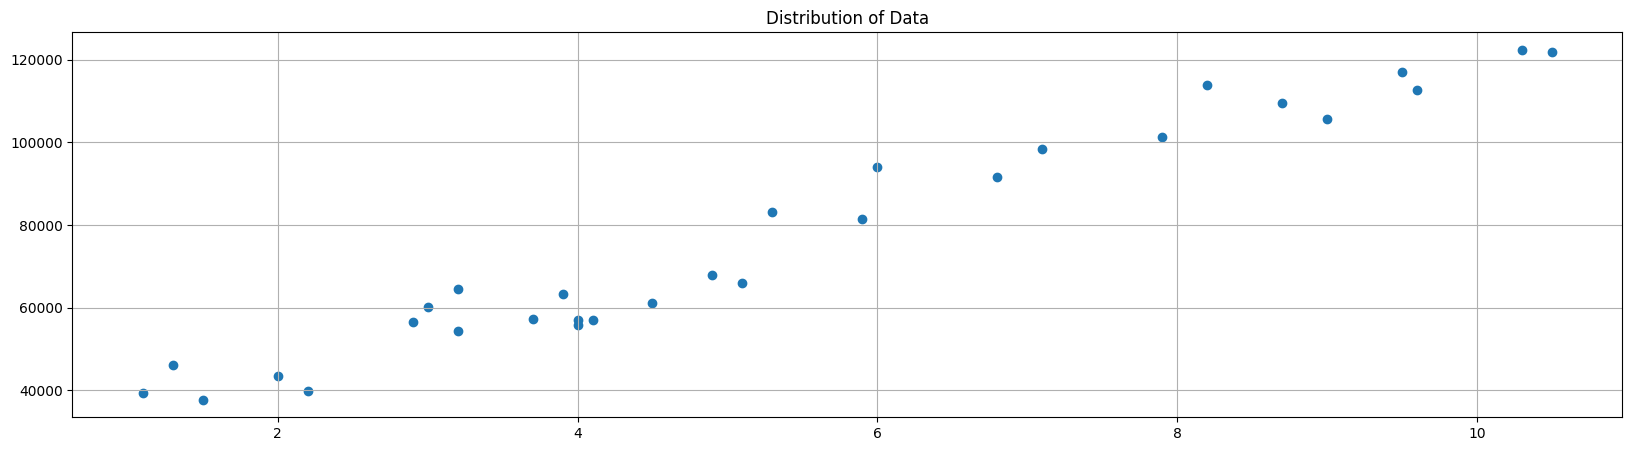

In [3]:
plt.figure(figsize=(20, 5))
plt.scatter(data['YearsExperience'], data['Salary'])
plt.title("Distribution of Data")
plt.grid()

In [4]:
x = data.iloc[ : , : -1]
y = data.iloc[ : , 1]

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

In [5]:
# Polynomial Equation : y = a*(x^1) + a*(x^2) + a*(x^3) + ...

poly = PolynomialFeatures(degree=5)

x_poly_train = poly.fit_transform(x_train) # Fit (Train) : calculate mean, std, scaling + Trasnform : apply

x_poly_test = poly.transform(x_test)

# x_poly_train # [x^0 - bias , x^1, x^2, x^3] - increase dimensions

# poly.get_feature_names_out()

poly_model = LinearRegression()

poly_model.fit(x_poly_train, y_train)

y_poly_pred_train = poly_model.predict(x_poly_train)

y_poly_pred_test = poly_model.predict(x_poly_test)

In [6]:
poly_display = pd.DataFrame(x_poly_train, columns=poly.get_feature_names_out())

poly_display.head()

,1,YearsExperience,YearsExperience^2,YearsExperience^3,YearsExperience^4,YearsExperience^5
0,1.0,10.3,106.09,1092.727,11255.0881,115927.40743
1,1.0,8.7,75.69,658.503,5728.9761,49842.09207
2,1.0,4.0,16.00,64.000,256.0000,1024.00000
3,1.0,1.1,1.21,1.331,1.4641,1.61051
4,1.0,2.2,4.84,10.648,23.4256,51.53632


In [7]:
y_poly_pred_train

array([120722.98072182, 108659.43463183,  59521.14521661,  38973.51514599,
        46929.65692665,  72002.64978817,  50852.35356822,  60513.3812675 ,
        59521.14521661, 103519.74633085,  40960.23529416,  42614.76539349,
       110319.23530491,  45831.75105196,  96416.04540538, 113277.67092545,
        82275.95121884, 123639.88878649,  93205.19313855,  52826.21942254,
        58562.84943268,  64800.31687932,  83554.42323047,  51482.44570152])

In [8]:
y_poly_pred_test

array([113960.93030723,  69520.5527358 , 105635.73681185,  74540.44674219,
        52826.21942254,  56750.4649517 ])

In [9]:
x_value = np.array([2.1]).reshape(-1,1)
x_value_poly = poly.transform(x_value)
y_value_pred = poly_model.predict(x_value_poly)

y_value_pred

c:\Users\dell\DEPI_ONL4_AIS2_S2\DEPI_ONL4_AIS2_S2_ML\DEPI_R4\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([46386.82262609])

In [10]:
x_range = np.linspace(x.min(), x.max(), 100).reshape(-1,1)
x_range_poly = poly.transform(x_range)
y_range_pred = poly_model.predict(x_range_poly)

c:\Users\dell\DEPI_ONL4_AIS2_S2\DEPI_ONL4_AIS2_S2_ML\DEPI_R4\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


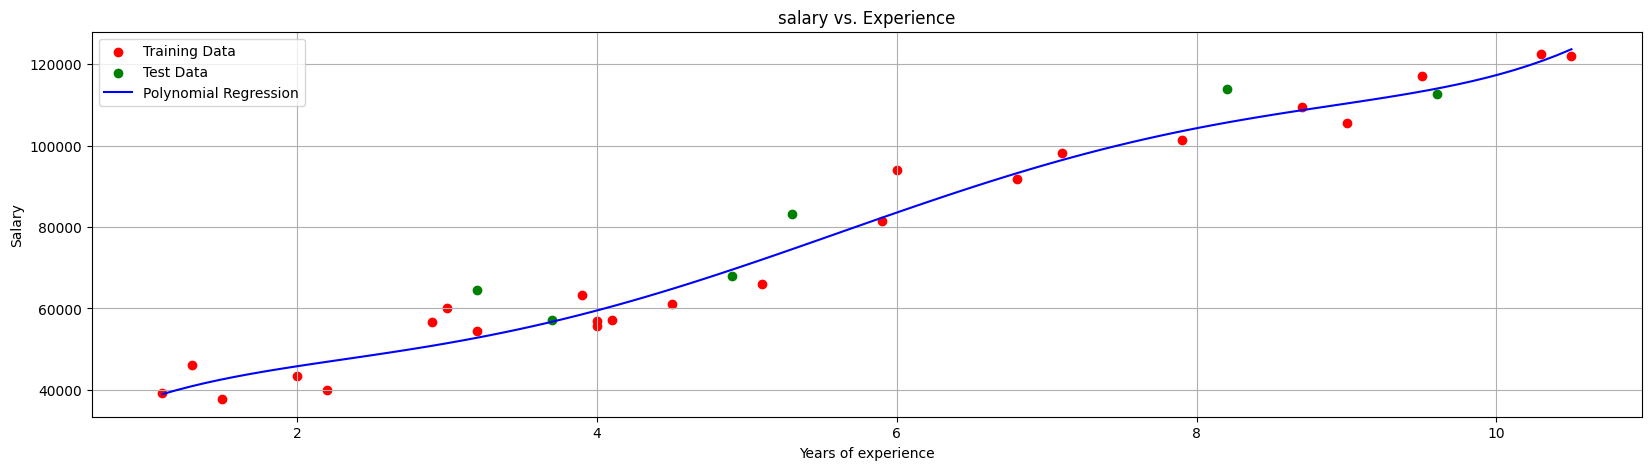

In [11]:
plt.figure(figsize=(20, 5))

plt.scatter(x_train, y_train, color="red", label="Training Data")
plt.scatter(x_test, y_test, color="green", label="Test Data")
plt.plot(x_range, y_range_pred, color="blue", label="Polynomial Regression")

plt.title("salary vs. Experience")
plt.xlabel("Years of experience")
plt.ylabel("Salary")
plt.legend()
plt.grid()
plt.show()

In [12]:
mse = mean_squared_error(y_test, y_poly_pred_test)
print(mse)

rmse = root_mean_squared_error(y_test, y_poly_pred_test)
print(rmse)

r2_score = r2_score(y_test, y_poly_pred_test)
print(r2_score)

46560480.97568058
6823.524087718939
0.9088471990418527
